<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/visualization/vis_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización Geoespacial 



## Introducción

<img src="https://geopandas.org/en/v1.1.0/_images/geopandas_logo.png" align="center" width = "300">


Datos espaciales son aquellos que contienen información sobre la ubicación o forma de objetos en el espacio. Python ofrece un ecosistema maduro para trabajar con ellos: desde manipulación hasta visualización estática e interactiva.

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from shapely.geometry import Point, LineString, Polygon

##  Conceptos fundamentales

### Tipos de geometría

| Tipo | Descripción | Ejemplo |
|---|---|---|
| `Point` | Un par de coordenadas (x, y) | Ubicación de una escuela |
| `LineString` | Secuencia ordenada de puntos | Trayectoria de una calle |
| `Polygon` | Área cerrada (anillo exterior + huecos) | Límite de una comuna |
| `MultiPoint` | Colección de puntos | Paradas de un bus |
| `MultiPolygon` | Colección de polígonos | Regiones con islas |

### Sistemas de referencia de coordenadas (CRS)

El CRS define cómo se proyectan las coordenadas sobre el espacio.

| CRS | EPSG | Uso típico |
|---|---|---|
| WGS 84 (geográfico) | `4326` | GPS, coordenadas lon/lat |
| Web Mercator | `3857` | Mapas web (Google, OSM) |
| UTM zona 19S | `32719` | Chile continental (metros) |

```python
# Verificar y reproyectar
gdf = gpd.read_file("mi_archivo.shp")
print(gdf.crs)                          # ver CRS actual
gdf_utm = gdf.to_crs(epsg=32719)        # reproyectar a UTM
```

> **Regla práctica**: usa `epsg=4326` para visualizar, `epsg=32719` (Chile) para medir distancias o áreas.


## Crear y cargar GeoDataFrames

### Desde coordenadas sueltas

In [9]:
datos = {
    "ciudad": ["Santiago", "Valparaíso", "Concepción"],
    "lat":    [-33.45, -33.04, -36.82],
    "lon":    [-70.67, -71.62, -73.05],
    "poblacion": [6_800_000, 300_000, 220_000]
}
df = pd.DataFrame(datos)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)
gdf.head()

,ciudad,lat,lon,poblacion,geometry
0,Santiago,-33.45,-70.67,6800000,POINT (-70.67 -33.45)
1,Valparaíso,-33.04,-71.62,300000,POINT (-71.62 -33.04)
2,Concepción,-36.82,-73.05,220000,POINT (-73.05 -36.82)


### Desde un archivo (shapefile, GeoJSON, GPKG)

In [7]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
mundo = gpd.read_file(url)

mundo.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


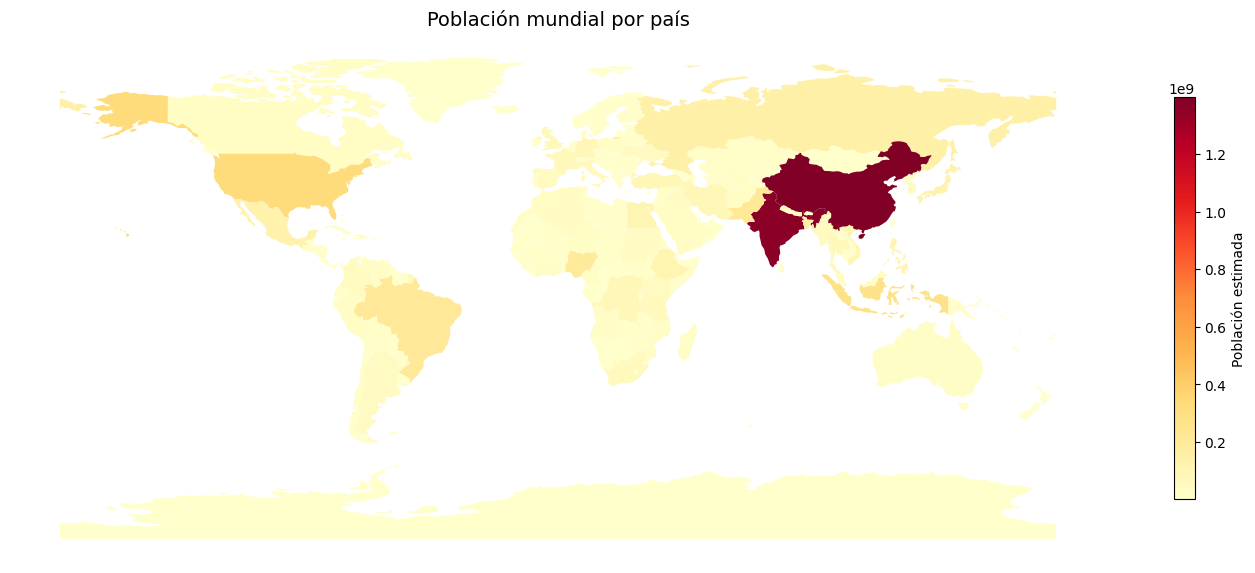

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
mundo.plot(
    column="POP_EST",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Población estimada", "shrink": 0.6},
    ax=ax
)
ax.set_title("Población mundial por país", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Exploración básica

In [10]:
print(gdf.shape)         # filas, columnas
print(gdf.crs)           # sistema de referencia
print(gdf.geometry.type) # tipo de geometría por fila
gdf.explore()            # mapa interactivo rápido (requiere folium)

(3, 5)
EPSG:4326
0    Point
1    Point
2    Point
dtype: object


## Mapa Coroplético

**Cuándo:** mostrar la variación de una variable numérica por área geográfica
(regiones, comunas, países). El color codifica el valor.

### Básico — `gdf.plot()`

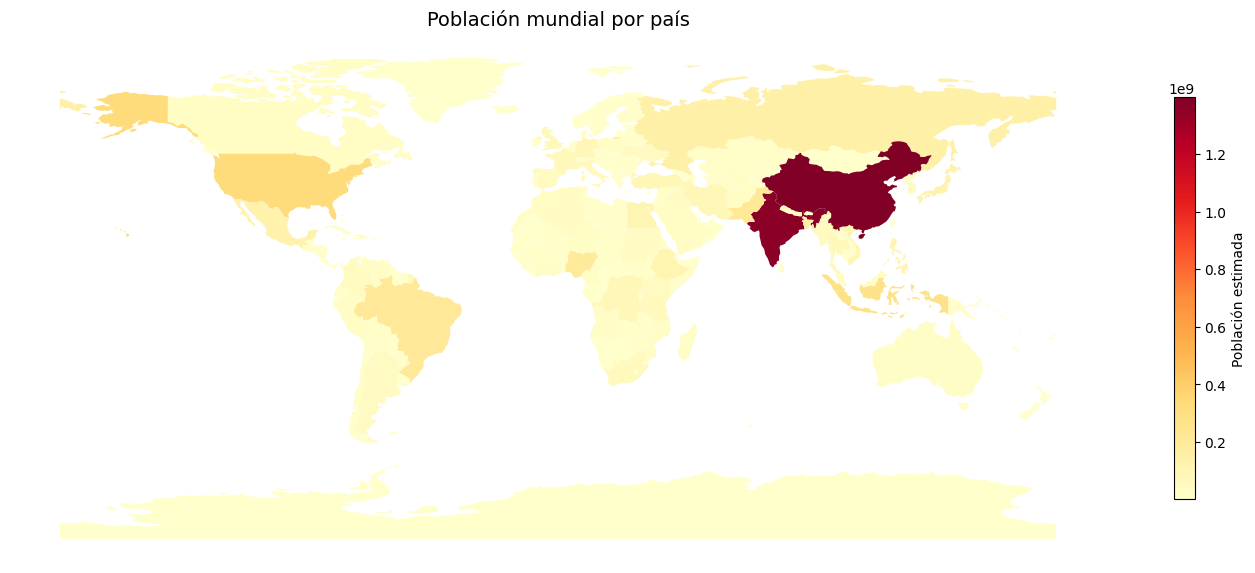

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))
mundo.plot(
    column="POP_EST",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Población estimada", "shrink": 0.6},
    ax=ax
)
ax.set_title("Población mundial por país", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Con escala logarítmica

Útil cuando los valores tienen rangos muy amplios:

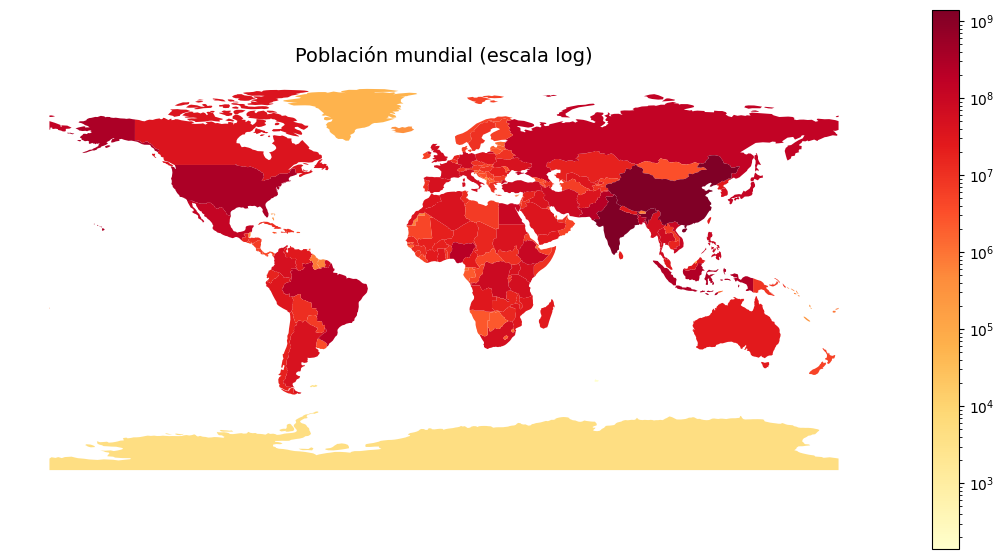

In [12]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 7))
mundo.plot(
    column="POP_EST",
    cmap="YlOrRd",
    norm=mcolors.LogNorm(
        vmin=mundo["POP_EST"].min(),
        vmax=mundo["POP_EST"].max()
    ),
    legend=True,
    ax=ax
)
ax.set_title("Población mundial (escala log)", fontsize=14)
ax.set_axis_off()
plt.show()

### Con clasificación manual (quantiles / breaks)


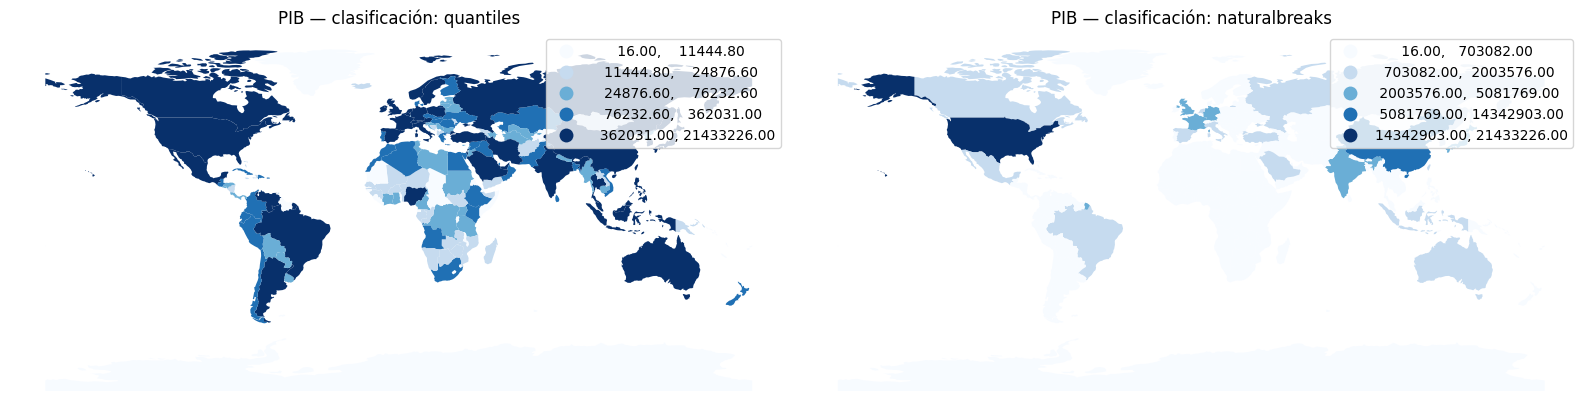

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, scheme in zip(axes, ["quantiles", "naturalbreaks"]):
    mundo.plot(
        column="GDP_MD",
        scheme=scheme,
        k=5,
        cmap="Blues",
        legend=True,
        ax=ax
    )
    ax.set_title(f"PIB — clasificación: {scheme}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

> `scheme` requiere el paquete `mapclassify`. Opciones: `quantiles`, `naturalbreaks`, `equalinterval`, `jenks`.


## Mapa de Puntos

**Cuándo:** ubicar eventos o entidades discretas sobre el mapa.
El tamaño o color del punto puede codificar una tercera variable.

### Puntos simples sobre un fondo base


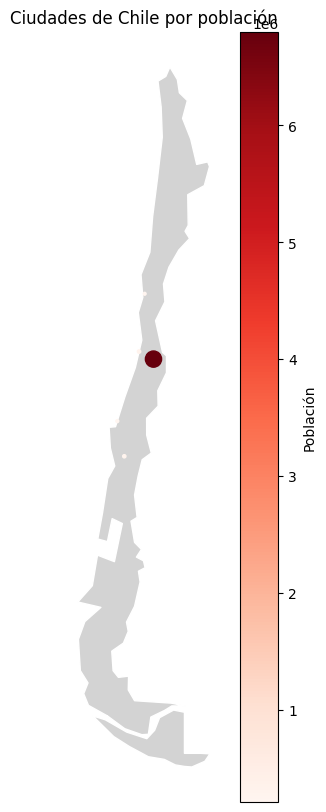

In [15]:
ciudades = gpd.GeoDataFrame({
    "ciudad":    ["Santiago", "Valparaíso", "Concepción", "La Serena", "Temuco"],
    "poblacion": [6_800_000, 300_000, 220_000, 210_000, 280_000],
    "geometry":  gpd.points_from_xy(
        [-70.67, -71.62, -73.05, -71.25, -72.59],
        [-33.45, -33.04, -36.82, -29.90, -38.73]
    )
}, crs="EPSG:4326")

chile = mundo[mundo["NAME"] == "Chile"]

fig, ax = plt.subplots(figsize=(6, 10))
chile.plot(ax=ax, color="lightgrey", edgecolor="white")
ciudades.plot(
    ax=ax,
    column="poblacion",
    cmap="Reds",
    markersize=ciudades["poblacion"] / 50_000,  # tamaño proporcional
    legend=True,
    legend_kwds={"label": "Población"}
)
ax.set_title("Ciudades de Chile por población")
ax.set_axis_off()
plt.show()

### Añadir etiquetas


In [16]:
for _, row in ciudades.iterrows():
    ax.annotate(
        row["ciudad"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=9
    )

## 5. Mapa de Líneas

**Cuándo:** representar rutas, ríos, calles o trayectorias.

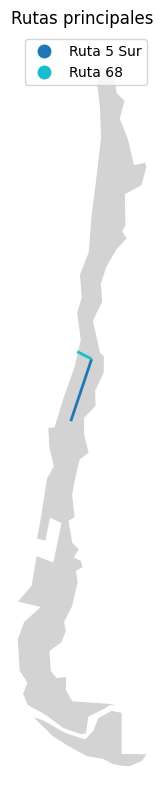

In [17]:
from shapely.geometry import LineString

rutas = gpd.GeoDataFrame({
    "nombre": ["Ruta 5 Sur", "Ruta 68"],
    "geometry": [
        LineString([(-70.67, -33.45), (-72.05, -36.82)]),
        LineString([(-70.67, -33.45), (-71.62, -33.04)])
    ]
}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(6, 10))
chile.plot(ax=ax, color="lightgrey", edgecolor="white")
rutas.plot(ax=ax, column="nombre", cmap="tab10",
           linewidth=2, legend=True)
ax.set_title("Rutas principales")
ax.set_axis_off()
plt.show()


## Operaciones espaciales útiles

### Buffer — área de influencia

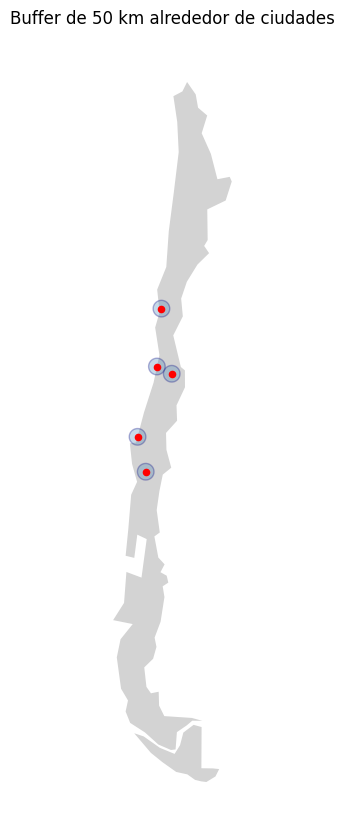

In [18]:
gdf_utm = ciudades.to_crs(epsg=32719)
buffer_50km = gdf_utm.copy()
buffer_50km["geometry"] = gdf_utm.geometry.buffer(50_000)  # 50 km

fig, ax = plt.subplots(figsize=(6, 10))
chile.to_crs(epsg=32719).plot(ax=ax, color="lightgrey")
buffer_50km.plot(ax=ax, alpha=0.3, color="steelblue", edgecolor="navy")
gdf_utm.plot(ax=ax, color="red", markersize=20)
ax.set_title("Buffer de 50 km alrededor de ciudades")
ax.set_axis_off()
plt.show()

## Mapas interactivos


### `gdf.explore()` — mapas rápidos con folium


In [23]:
mundo.explore(
    column="POP_EST",
    cmap="YlOrRd",
    tooltip=["NAME", "POP_EST"],
    popup=True,
    tiles="CartoDB positron"
)

### folium — control total


In [26]:
import folium

ciudades = gpd.GeoDataFrame({
    "ciudad":    ["Santiago", "Valparaíso", "Concepción", "La Serena", "Temuco"],
    "poblacion": [6_800_000, 300_000, 220_000, 210_000, 280_000],
    "geometry":  gpd.points_from_xy(
        [-70.67, -71.62, -73.05, -71.25, -72.59],
        [-33.45, -33.04, -36.82, -29.90, -38.73]
    )
}, crs="EPSG:4326")

chile = mundo[mundo["NAME"] == "Chile"]

m = folium.Map(location=[-33.45, -70.67], zoom_start=5)

for _, row in ciudades.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row["poblacion"] / 500_000,
        color="crimson",
        fill=True,
        tooltip=f"{row['ciudad']}: {row['poblacion']:,}"
    ).add_to(m)

m  # en Jupyter renderiza inline

## Mapas de calor (densidad espacial)
### KDE espacial con scipy


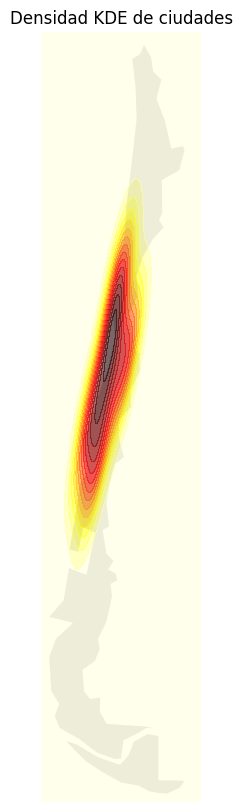

In [30]:
from scipy.stats import gaussian_kde

coords = np.vstack([ciudades.geometry.x, ciudades.geometry.y])
kde = gaussian_kde(coords)

# Evaluar sobre una grilla
xi, yi = np.mgrid[-76:-66:200j, -56:-17:200j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)

fig, ax = plt.subplots(figsize=(6, 10))
chile.plot(ax=ax, color="lightgrey", edgecolor="white")
ax.contourf(xi, yi, zi, levels=15, cmap="hot_r", alpha=0.6)
ax.set_title("Densidad KDE de ciudades")
ax.set_axis_off()
plt.show()

### Heatmap con folium


In [31]:
from folium.plugins import HeatMap

coords_lista = [[row.geometry.y, row.geometry.x]
                for _, row in ciudades.iterrows()]

m = folium.Map(location=[-35, -71], zoom_start=5)
HeatMap(coords_lista, radius=40).add_to(m)
m

## Subplots temáticos

Útil para comparar variables en el mismo espacio geográfico:


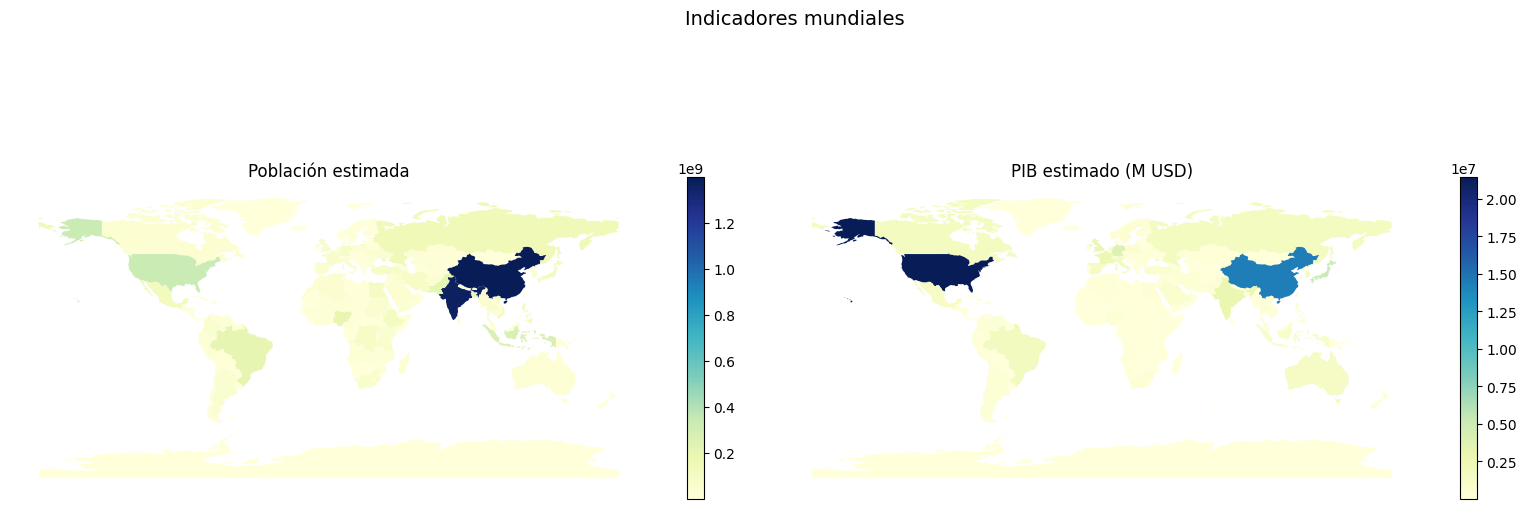

In [32]:
variables = ["POP_EST", "GDP_MD"]
titulos   = ["Población estimada", "PIB estimado (M USD)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, titulo in zip(axes, variables, titulos):
    mundo.plot(
        column=col,
        cmap="YlGnBu",
        legend=True,
        legend_kwds={"shrink": 0.6},
        ax=ax
    )
    ax.set_title(titulo, fontsize=12)
    ax.set_axis_off()

plt.suptitle("Indicadores mundiales", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()